## APPLIED STATISTICS

### Turma 16DTSR


#### Trabalho prático usando o Python

#### Habilidades desenvolvidas: Análise Exploratória de Dados. Detecção de outliers.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [ ]:
#lendo a base de dados
cadastro = pd.read_csv('cadastro.csv')

In [ ]:
cadastro.columns

In [ ]:
#visualizando o conteúdo da base
#cadastro.head()
cadastro.head().T

In [ ]:
#formato das variáveis
cadastro.info()

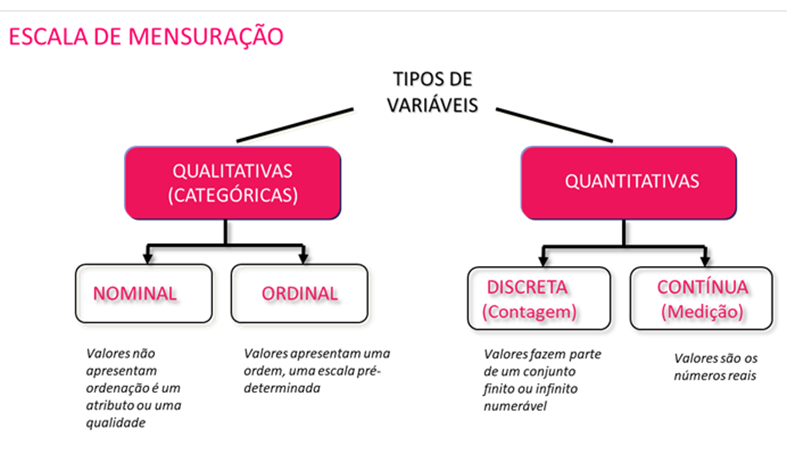

In [ ]:
# contagem de observações com dados
cadastro.count()

In [ ]:
# contagem de observações diferentes
cadastro.nunique()

In [ ]:
# é missing ou não ( NA Not Avaliable)
# Retorna verdadeiro ou falso para presença de dados faltantes (missing value)
cadastro.isna().T

In [ ]:
# Contagem de observações com missing
cadastro.isna().sum()

In [ ]:
# % de observações com missing
cadastro.isna().sum()/len(cadastro)*100

In [ ]:
# Descritivo das variáveis - medidas resumo  De todas as variáveis numéricas

#cadastro.describe()
cadastro.describe().T

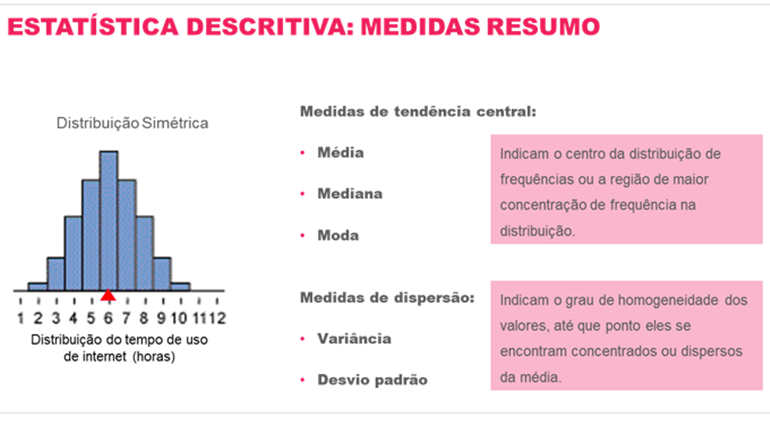

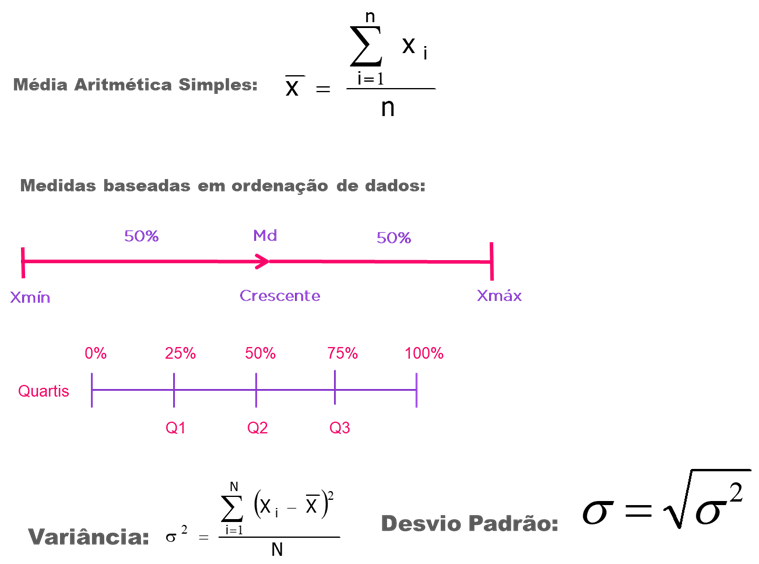

In [ ]:
# colocando as medidas resumo em um objeto
Describe=cadastro.describe()
print(Describe)

In [ ]:
pd.set_option('display.float_format','{:.2f}'.format)

In [ ]:
Describe=cadastro.describe().round(0)
print(Describe)

In [ ]:
#Preprocessing
# mudar o formato da variável number para string
cadastro['NUM_CPF'] = cadastro['NUM_CPF'].astype(str)
cadastro['CHAVE_CONTRATO'] = cadastro['CHAVE_CONTRATO'].astype(str)
cadastro['CEP'] = cadastro['CEP'].astype(str)
cadastro['CEP_A'] = cadastro['CEP_A'].astype(str)
cadastro['NUMERO'] = cadastro['NUMERO'].astype(str)
cadastro['LATITUDE'] = cadastro['LATITUDE'].astype(str)
cadastro['LONGITUDE'] = cadastro['LONGITUDE'].astype(str)
cadastro['CELULAR'] = cadastro['CELULAR'].astype(str)
cadastro['DDD_CELULAR'] = cadastro['DDD_CELULAR'].astype(str)
cadastro['CELULAR_2'] = cadastro['CELULAR_2'].astype(str)
cadastro['DDD_CELULAR_2'] = cadastro['DDD_CELULAR_2'].astype(str)
cadastro['COD_BANCO'] = cadastro['COD_BANCO'].astype(str)
cadastro['NUM_AGENCIA'] = cadastro['NUM_AGENCIA'].astype(str)
cadastro['NUM_CONTA'] = cadastro['NUM_CONTA'].astype(str)
cadastro['CNPJ_CREDOR'] = cadastro['CNPJ_CREDOR'].astype(str)
cadastro['STATUS_CONSENTIMENTO'] = cadastro['STATUS_CONSENTIMENTO'].astype(str)



In [ ]:
# avaliando as alterações feitas nos formatos das variáveis
cadastro.info()

In [ ]:
# descritivo das variáveis após as alterações realizadas
cadastro.describe().round(2)

In [ ]:
cadastro.isna().sum()

In [ ]:
# observando alguns campos...
cadastro.head(5).T

In [ ]:
# indicando e alterando campos
# Mudar a categoria "nan" para "NaN" (identificação de missing data)
# isto aconteceu quando mudamos o formato de algumas variáveis

cadastro.replace('nan', np.nan, inplace=True)

In [ ]:
cadastro.head(5).T

In [ ]:
cadastro.isna().sum()

In [ ]:
cadastro.isna().sum()/len(cadastro)*100

In [ ]:
!pip install missingno
import missingno as msno

# Visualizando os dados faltantes? A biblioteca MissingNo permite a visualização dos dados nulos (‘NaN’) em seu dataset

In [ ]:
# Análise da completude das variáveis do banco de dados usando o gráfico de barra. No eixo "Y" é a frequência relativa e no
# eixo "X" as variáveis.
msno.bar(cadastro)

In [ ]:
# Análise da completude das variáveis em uma amostra de tamanho 100 (n=100) do banco de dados usando o gráfico de barra.
# No eixo "Y" é a frequência relativa e no eixo "X" as variáveis.

msno.bar(cadastro.sample(100))

## Imputação de dados faltantes

In [ ]:
cadastro["IDADE"].describe()

# Idade é uma variável que encontramos com 5 dados faltantes

O que podemos fazer quando nossas variáveis tem dados faltantes?

Avaliar a quantidade de valores missing presente na variável, e eliminá-los caso tenha um “alto” percentual.

Tratamento de valores missing:
    Eliminar todo o registro (toda a linha), ou coluna (campo) de variável que contenha valores faltantes.
    ==> Processo simples porém há perda de informação.
    Variáveis Quantitativas,  a mais simples, é o uso da média ou mediana.
    ==> Use a média ou mediana da variável por algum tipo de classificação das entidades.
    ==> Exemplo: mesma região, mesmo segmento, mesma classe social, mesmo sexo, etc.
    Usar técnicas mais avançadas para estimar os campos, técnicas mais usadas: Análise de Regressão,
    Árvores de  Regressão, KNN ou outras imputações com machine learning.


In [ ]:

print("Media :",np.mean(cadastro['IDADE']))
print("Mediana :",(cadastro['IDADE'].median()))

print("Minimo :",np.min(cadastro['IDADE']))
print("Maximo :",np.max(cadastro['IDADE']))


In [ ]:
# avalie a variabilidade da variável
print("desvio :",np.std(cadastro['IDADE']))

In [ ]:
# percebam que estamos utilizando uma medida com dados incoerentes, o que fazer?

In [ ]:
# Imputação de dados faltantes usando a media? ou qual métrica?

cadastro['Idade_i'] = cadastro['IDADE'].fillna(value=cadastro['IDADE'].XXXX())


In [ ]:
# Análise descritiva das variáveis
cadastro.describe().round(2)

In [ ]:
cadastro.info()

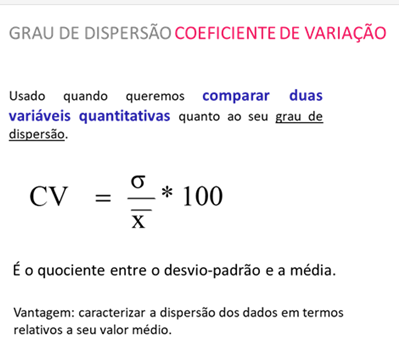

In [ ]:
# CV = desvio padrão/média

desc = cadastro.describe().T

desc['CV'] = desc['std']/desc['mean']*100

In [ ]:
desc.round(2)

### Interpretação do CV



         Renda presumida:
         O desvio padrão é 10.76 vezes o valor da média. Isso indica presença de outliers. Quantos outliers?

         Recomendado é até 0,3 ou 30%. Valores acima de 30% indicam presença de outliers. (Critério do IBGE)
    


## Histograma e o Boxplot

### são gráficos que representam a distribuição de um conjunto de dados
### O histograma é um gráfico de "barras", enquanto o boxplot é um diagrama de caixa


### Histograma

#### Representa a distribuição de frequências
#### A base de cada barra representa uma classe
#### A altura de cada barra representa a frequência absoluta de cada classe
#### É útil para visualizar a distribuição dos dados como um todo
#### Pode ser usado para verificar se os dados se aproximam de uma distribuição normal.


### Box-Plot

#### Representa a distribuição de um conjunto de dados
#### Também é conhecido como "Diagrama de Caixa"
#### Resume cinco estatísticas: valor mínimo, primeiro quartil, mediana, terceiro quartil e valor máximo
#### É útil para identificar a existência de outliers (valores discrepantes)
#### Pode ser usado para analisar a posição, a dispersão, a simetria, as caudas e os outliers dos dados.


## Analisando a Variável Idade

In [ ]:

sb.histplot(x="Idade_i", data=cadastro, bins=10);

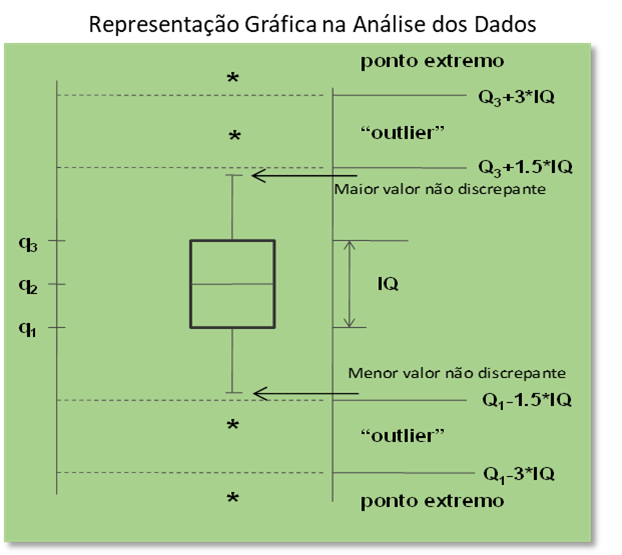

In [ ]:
sb.boxplot(y="Idade_i", data=cadastro);

In [ ]:
# opção sobre como eliminar outliers é achatamento de algum valor descrepante

#1 cadastro.loc[cadastro["Idade_i"]>=1000, "Idade_i"] = 100
cadastro.loc[cadastro["Idade_i"]>=1000, "Idade_i"] = cadastro["IDADE"].median()


In [ ]:
cadastro.describe().round(2)

In [ ]:
# O Box Plot (desenho esquemático) informa medidas de posição, dispersão, assimetria, caudas e dados atípicos (outliers).
#     A posição central é dada pela mediana e a dispersão pela amplitude inter-quartílica.
#     As medidas de posição q1, q2 e q3 informam a assimetria da distribuição.
#     Os comprimentos das caudas são dados pelas linhas que vão do retângulo aos valores distantes e pelos valores atípicos.
sb.boxplot(y="Idade_i", data=cadastro);

### Muito cuidado ao avaliar outliers vs um público específico

In [ ]:

fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1)

sb.boxplot(x="Idade_i", data=cadastro, ax=ax1)
sb.histplot(x="Idade_i", data=cadastro, bins=10, kde=True, ax=ax2)

plt.show()

In [ ]:
cadastro["Idade_i"].describe()

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

fig, (ax1, ax2) = plt.subplots(
    nrows=2,
    ncols=1,
    sharex=True,
    gridspec_kw={"height_ratios": (0.15, 0.85), "hspace": 0.02},
)

sb.boxplot(x="Idade_i", data=cadastro, ax=ax1)
sb.histplot(x="Idade_i", data=cadastro, bins=10, kde=True, ax=ax2)

ax2.xaxis.set_major_locator(mtick.MultipleLocator(base=5.0))
ax2.tick_params(axis="x", rotation=90)

for ax in (ax1, ax2):
    ax.grid(True, linestyle="--", color="gray", alpha=0.5)
    ax.set_axisbelow(True)

ax2.axvline(cadastro["Idade_i"].mean(), color="C1", linestyle="--", label="Média")
ax2.axvline(cadastro["Idade_i"].median(), color="C2", linestyle="--", label="Mediana")
ax2.axvline(cadastro["Idade_i"].mode()[0], color="C3", linestyle="--", label="Moda")

ax2.legend()

plt.show()

## Analisando a Variável renda Presumida

In [ ]:
sb.boxplot(y="RENDA_PRESUMIDA", data=cadastro);

In [ ]:
# excluindo renda presumida acima de 100mil
renda = cadastro[(cadastro['RENDA_PRESUMIDA'] <100000)]

fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1)

sb.boxplot(x="RENDA_PRESUMIDA", data=renda, ax=ax1)
sb.histplot(x="RENDA_PRESUMIDA", data=renda, bins=10, kde=True, ax=ax2)

plt.show()
renda.describe().round(2)

In [ ]:
# ecluindo renda presumida acima de 10mil
renda = cadastro[(cadastro['RENDA_PRESUMIDA'] <10000)]

fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1)

sb.boxplot(x="RENDA_PRESUMIDA", data=renda, ax=ax1)
sb.histplot(x="RENDA_PRESUMIDA", data=renda, bins=10, kde=True, ax=ax2)

plt.show()
renda.describe().round(2)

#### Exluindo as observações acima de 10.000 ficamos com 417 observações mas esse é o melhor corte?

### Trabalhando com o BoxPLot

    Box Plot da Renda Presumida
    mínimo =  
    máximo =  
    Quartil 1 (Q1) =  
    Quartil 2 (Q2) =  
    Quartil 3 (Q3) =  
    Inter-quartil = Q3 - Q1 =  

    Limite1  = Q3 + 3 * IQ =  
    Limite2  = Q3 + 1.5*IQ =  
    Limite3  = Q1 - 1.5*IQ =  
    Limite4  = Q1 - 3*IQ =  

In [ ]:
cadastro.describe().round(2)

In [ ]:
print('Minimo = ', min(cadastro['RENDA_PRESUMIDA']))

In [ ]:
print('Maximo = ', max(cadastro['RENDA_PRESUMIDA']))

In [ ]:
Q1 = np.percentile(cadastro['RENDA_PRESUMIDA'], 25)
print(Q1)
print('Quartil1 (Q1) = ', np.percentile(cadastro['RENDA_PRESUMIDA'], 25))

In [ ]:
Q2=np.percentile(cadastro['RENDA_PRESUMIDA'], 50)
print(Q2)
print('Quartil2 (Q2) = ', np.percentile(cadastro['RENDA_PRESUMIDA'], 50))

In [ ]:
Q3=np.percentile(cadastro['RENDA_PRESUMIDA'], 75)
print(Q3)
print('Quartil3 (Q3) = ', np.percentile(cadastro['RENDA_PRESUMIDA'], 75))

In [ ]:
# distância Inter-quartílica

IQ = np.percentile(cadastro['RENDA_PRESUMIDA'], 75) - np.percentile(cadastro['RENDA_PRESUMIDA'], 25)
print(IQ)
print('Inter-quartil (IQ) =', np.percentile(cadastro['RENDA_PRESUMIDA'], 75) - np.percentile(cadastro['RENDA_PRESUMIDA'], 25))

In [ ]:
limite1 = Q3+3*IQ
print(limite1)

In [ ]:
limite2 = Q3+1.5*IQ
print(limite2)

In [ ]:
limite3=Q1-1.5*IQ
print(limite3)

In [ ]:
limite4 = Q1-3*IQ
print(limite4)

In [ ]:
# Quantos outliers? Pontos extremos?
print('Outliers Superior: ', cadastro.loc[(cadastro.RENDA_PRESUMIDA >= limite2) & (cadastro.RENDA_PRESUMIDA <= limite1), 'RENDA_PRESUMIDA'].count())
print('Outliers Inferior: ', cadastro.loc[(cadastro.RENDA_PRESUMIDA >= limite4) & (cadastro.RENDA_PRESUMIDA <= limite3), 'RENDA_PRESUMIDA'].count())
print('Pontos Extremos: ', cadastro.loc[(cadastro.RENDA_PRESUMIDA >= limite1) | (cadastro.RENDA_PRESUMIDA <= limite4), 'RENDA_PRESUMIDA'].count())


In [ ]:
# Criar uma variável outlier_renda no Data Frame, sendo 0 = não outlier, 1= outlier e 2 = ponto extremo
cadastro.loc[(cadastro.RENDA_PRESUMIDA >= limite2) & (cadastro.RENDA_PRESUMIDA <= limite1), 'outlier_renda']=1
cadastro.loc[(cadastro.RENDA_PRESUMIDA <= limite3) & (cadastro.RENDA_PRESUMIDA >= limite4), 'outlier_renda']=-1
cadastro.loc[(cadastro.RENDA_PRESUMIDA > limite1) | (cadastro.RENDA_PRESUMIDA < limite4) , 'outlier_renda']=2
cadastro.loc[(cadastro.RENDA_PRESUMIDA > limite3) & (cadastro.RENDA_PRESUMIDA < limite2), 'outlier_renda']=0

In [ ]:
cadastro.info()

In [ ]:
# Tabela de frequência da variável outlier_renda
freq_outlier_renda = pd.pivot_table(cadastro,index='outlier_renda', values='NUM_CPF', aggfunc=np.count_nonzero)
freq_outlier_renda['%'] = ((pd.pivot_table(cadastro,index='outlier_renda', values='NUM_CPF', aggfunc=np.count_nonzero)/cadastro['NUM_CPF'].count())*100).round(2)

In [ ]:
# quantidade de observações
print(freq_outlier_renda)

# Um ponto de atenção aqui!!!

## Quantidade de outliers

In [ ]:
################################################
########### REMOVER OS OUTLIERS ############
################################################

# Removendo os Outliers
cadastroSemOutlier = cadastro.loc[cadastro.outlier_renda == 0.0]

print('Mínimo = ', min(cadastroSemOutlier['RENDA_PRESUMIDA']))

print('Máximo = ', max(cadastroSemOutlier['RENDA_PRESUMIDA']))

print('Média = ', (cadastroSemOutlier['RENDA_PRESUMIDA']).mean())

print('STD = ', cadastroSemOutlier['RENDA_PRESUMIDA'].std())

print('Coeficiente de Variação = ', (cadastroSemOutlier['RENDA_PRESUMIDA'].std() / cadastroSemOutlier['RENDA_PRESUMIDA'].mean()))

print('Mediana = ', (cadastroSemOutlier['RENDA_PRESUMIDA']).median())


In [ ]:
# Gráfico histograma  Antes e Depois
fig, axes = plt.subplots(nrows=1, ncols=2,figsize=(20,4))

plt.subplot(1,2,1)
plt.hist(cadastro['RENDA_PRESUMIDA'], bins=10)
plt.ylabel('Frequência')
plt.xlabel('RENDA_PRESUMIDA BASE INICIAL (R$)')
plt.subplot(1,2,2)
plt.hist(cadastroSemOutlier['RENDA_PRESUMIDA'], bins=10)
plt.ylabel('Frequência')
plt.xlabel('RENDA_PRESUMIDA SEM OUTLIERS(R$)')

In [ ]:
# Resultado da análise

fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1)

sb.boxplot(x="RENDA_PRESUMIDA", data=cadastroSemOutlier, ax=ax1)
sb.histplot(x="RENDA_PRESUMIDA", data=cadastroSemOutlier, bins=10, kde=True, ax=ax2)

plt.show()